In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df= pd.read_csv('spotify.csv')
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [5]:
df.columns

Index(['user_id', 'country', 'age', 'signup_date', 'subscription_type',
       'subscription_status', 'months_inactive', 'inactive_3_months_flag',
       'ad_interaction', 'ad_conversion_to_subscription',
       'music_suggestion_rating_1_to_5', 'avg_listening_hours_per_week',
       'favorite_genre', 'most_liked_feature', 'desired_future_feature',
       'primary_device', 'playlists_created', 'avg_skips_per_day'],
      dtype='object')

In [6]:
df.describe()

,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [9]:
drop_cols = [
    'user_id',
    'session_id',
    'last_active_date',
    'account_creation_date',
    'favorite_artists']
df = df.drop(columns=drop_cols, errors='ignore')

In [10]:
df.head()

,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [11]:
X = df.drop(columns= ['subscription_status'])
X.head()

,country,age,signup_date,subscription_type,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,France,25,2021-08-19,Premium Duo,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,Indonesia,20,2022-06-06,Premium Family,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,Italy,53,2024-01-04,Premium Individual,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,Italy,48,2018-08-26,Premium Individual,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,Australia,18,2020-05-29,Free,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [12]:
y= df['subscription_status']
y.head()

0    Active
1    Active
2    Active
3    Active
4    Active
Name: subscription_status, dtype: object

In [13]:
X.isnull().sum()

country                           0
age                               0
signup_date                       0
subscription_type                 0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         50000 non-null  object 
 1   age                             50000 non-null  int64  
 2   signup_date                     50000 non-null  object 
 3   subscription_type               50000 non-null  object 
 4   months_inactive                 50000 non-null  int64  
 5   inactive_3_months_flag          50000 non-null  int64  
 6   ad_interaction                  50000 non-null  object 
 7   ad_conversion_to_subscription   50000 non-null  object 
 8   music_suggestion_rating_1_to_5  50000 non-null  int64  
 9   avg_listening_hours_per_week    50000 non-null  float64
 10  favorite_genre                  50000 non-null  object 
 11  most_liked_feature              50000 non-null  object 
 12  desired_future_feature          

In [15]:
X.duplicated().sum()

np.int64(0)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'age'),
  Text(1, 0, 'months_inactive'),
  Text(2, 0, 'inactive_3_months_flag'),
  Text(3, 0, 'music_suggestion_rating_1_to_5'),
  Text(4, 0, 'avg_listening_hours_per_week'),
  Text(5, 0, 'playlists_created'),
  Text(6, 0, 'avg_skips_per_day')])

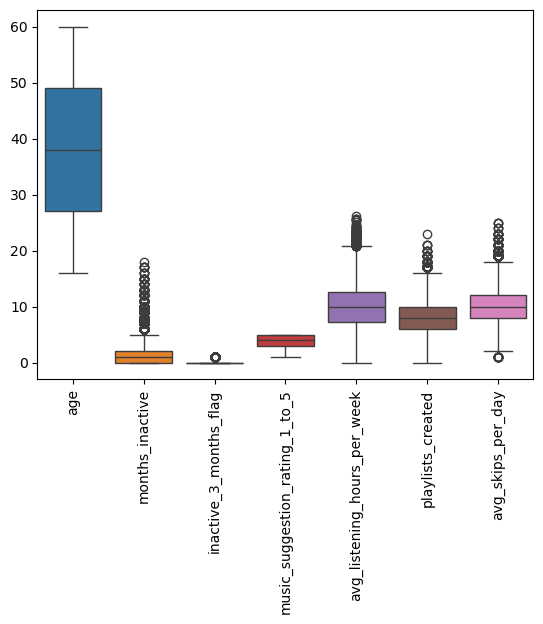

In [16]:
sns.boxplot(X)
plt.xticks(rotation = 90)

In [17]:
import numpy as np

columns = ['months_inactive', 'inactive_3_months_flag', 'avg_listening_hours_per_week','playlists_created','avg_skips_per_day']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
               np.where(df[col] > upper, upper, df[col]))

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'age'),
  Text(1, 0, 'months_inactive'),
  Text(2, 0, 'inactive_3_months_flag'),
  Text(3, 0, 'music_suggestion_rating_1_to_5'),
  Text(4, 0, 'avg_listening_hours_per_week'),
  Text(5, 0, 'playlists_created'),
  Text(6, 0, 'avg_skips_per_day')])

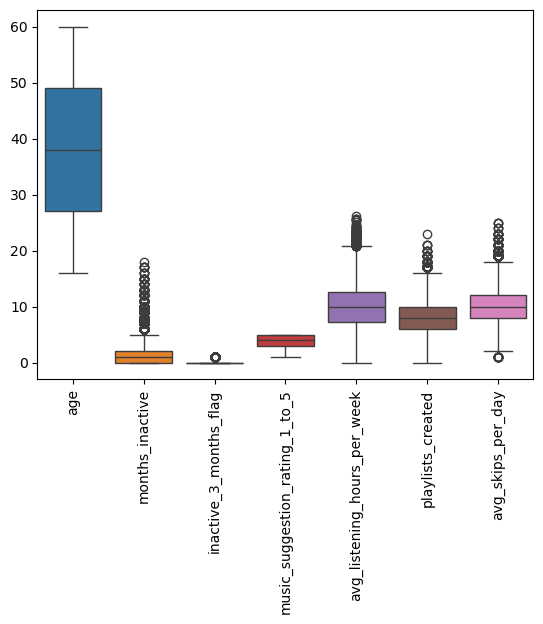

In [18]:
sns.boxplot(X)
plt.xticks(rotation = 90)

In [19]:
columns = ['months_inactive', 'inactive_3_months_flag', 'avg_listening_hours_per_week','playlists_created','avg_skips_per_day']
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'age'),
  Text(1, 0, 'months_inactive'),
  Text(2, 0, 'inactive_3_months_flag'),
  Text(3, 0, 'music_suggestion_rating_1_to_5'),
  Text(4, 0, 'avg_listening_hours_per_week'),
  Text(5, 0, 'playlists_created'),
  Text(6, 0, 'avg_skips_per_day')])

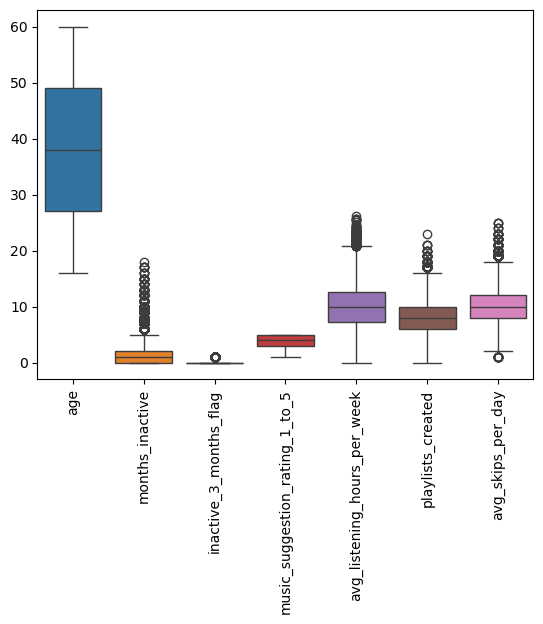

In [20]:
sns.boxplot(X)
plt.xticks(rotation = 90)

In [20]:
X.var

<bound method DataFrame.var of          country  age signup_date   subscription_type  months_inactive  \
0         France   25  2021-08-19         Premium Duo                0   
1      Indonesia   20  2022-06-06      Premium Family                0   
2          Italy   53  2024-01-04  Premium Individual                0   
3          Italy   48  2018-08-26  Premium Individual                1   
4      Australia   18  2020-05-29                Free                0   
...          ...  ...         ...                 ...              ...   
49995      India   33  2022-09-23                Free                2   
49996      Italy   35  2023-11-17      Premium Family                0   
49997     Brazil   33  2024-11-14  Premium Individual                0   
49998        USA   43  2021-05-31                Free                0   
49999  Indonesia   38  2024-07-05                Free                3   

       inactive_3_months_flag ad_interaction ad_conversion_to_subscription  \
0 

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 16)
(10000, 16)
(40000,)
(10000,)


In [22]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [23]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers=[('t1',OrdinalEncoder(),cat_cols),
                                            ('t2',StandardScaler(),num_cols)])
# Let us apply fit_transform on Train Data
X_train_trans=transformer.fit_transform(X_train)
# Let us apply transform on test data
X_test_trans=transformer.transform(X_test)

In [24]:
X_train_trans=pd.DataFrame(X_train_trans)
X_train_trans.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,8.0,519.0,3.0,0.0,0.0,10.0,4.0,4.0,2.0,0.768014,-0.785386,-0.537155,-0.574914,0.876431,0.356336,-0.008730
1,5.0,569.0,1.0,0.0,0.0,6.0,7.0,5.0,0.0,0.382757,-0.275238,-0.537155,-0.574914,-0.089343,0.001367,-1.270544
2,8.0,2490.0,4.0,0.0,0.0,1.0,2.0,4.0,2.0,-0.387758,-0.785386,-0.537155,-0.574914,0.109345,-0.353603,-0.324184
3,9.0,326.0,0.0,0.0,0.0,9.0,1.0,3.0,3.0,1.230323,0.234911,-0.537155,1.218750,0.868886,0.711306,-0.324184
4,7.0,1530.0,0.0,1.0,0.0,1.0,3.0,4.0,3.0,-0.156603,-0.275238,-0.537155,1.218750,1.193326,1.421246,-0.955090


In [25]:
X_test_trans=pd.DataFrame(X_test_trans)
X_test_trans.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,8.0,454.0,0.0,0.0,0.0,1.0,0.0,5.0,3.0,1.307375,-0.785386,-0.537155,1.218750,1.464950,-1.063543,1.568537
1,2.0,2586.0,0.0,0.0,0.0,8.0,3.0,3.0,3.0,0.536860,-0.275238,-0.537155,-2.368579,0.008743,0.356336,-0.639637
2,6.0,235.0,2.0,0.0,0.0,2.0,2.0,0.0,2.0,1.692632,2.275504,1.861661,1.218750,-0.406238,-0.353603,1.253083
3,6.0,522.0,0.0,0.0,0.0,7.0,0.0,5.0,0.0,1.615581,-0.275238,-0.537155,0.321918,-0.464084,-0.353603,-0.955090
4,4.0,2314.0,0.0,0.0,0.0,5.0,0.0,4.0,2.0,1.384426,-0.275238,-0.537155,0.321918,0.941822,-0.708573,-0.008730


In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_trans,y_train)

KNeighborsClassifier()

In [27]:
y_train_trans=knn.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of knn:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of knn:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of knn:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of knn:',f1)

  File "c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


acc Score of knn: 0.892925
classification report Score of knn:
              precision    recall  f1-score   support

      Active       0.99      0.89      0.94     37302
    Inactive       0.38      0.89      0.53      2698

    accuracy                           0.89     40000
   macro avg       0.68      0.89      0.73     40000
weighted avg       0.95      0.89      0.91     40000

confusion metrix Score of knn:
[[33323  3979]
 [  304  2394]]
f1 Score of knn: 0.9118411304858218


In [28]:
y_pred = knn.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(10000,)
(10000,)


In [29]:
y_pred=knn.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of knn:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of knn:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of knn:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of knn:',f1)

acc Score of knn: 0.8576
classification report Score of knn:
              precision    recall  f1-score   support

      Active       0.98      0.87      0.92      9616
    Inactive       0.16      0.62      0.25       384

    accuracy                           0.86     10000
   macro avg       0.57      0.74      0.59     10000
weighted avg       0.95      0.86      0.90     10000

confusion metrix Score of knn:
[[8337 1279]
 [ 145  239]]
f1 Score of knn: 0.8955891625440602


In [30]:
from sklearn.naive_bayes import GaussianNB
ng=GaussianNB()
ng.fit(X_train_trans,y_train)

GaussianNB()

In [31]:
y_train_trans=ng.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Naive:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Naive:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Naive:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Naive:',f1)

acc Score of Naive: 0.9354
classification report Score of Naive:
              precision    recall  f1-score   support

      Active       0.92      1.00      0.96     31043
    Inactive       1.00      0.71      0.83      8957

    accuracy                           0.94     40000
   macro avg       0.96      0.86      0.90     40000
weighted avg       0.94      0.94      0.93     40000

confusion metrix Score of Naive:
[[31043     0]
 [ 2584  6373]]
f1 Score of Naive: 0.9312461657684842


In [32]:
y_pred = ng.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(10000,)
(10000,)


In [33]:
y_pred=ng.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Naive:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Naive:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Naive:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Naive:',f1)

acc Score of Naive: 0.9352
classification report Score of Naive:
              precision    recall  f1-score   support

      Active       0.92      1.00      0.96      7834
    Inactive       1.00      0.70      0.82      2166

    accuracy                           0.94     10000
   macro avg       0.96      0.85      0.89     10000
weighted avg       0.94      0.94      0.93     10000

confusion metrix Score of Naive:
[[7834    0]
 [ 648 1518]]
f1 Score of Naive: 0.9307877631756523


In [34]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini',random_state=42)
model.fit(X_train_trans,y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
y_train_trans=model.predict(X_train_trans)

In [36]:
y_train_trans=model.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Tree:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Tree:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Tree:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Tree:',f1)

acc Score of Tree: 1.0
classification report Score of Tree:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00     33627
    Inactive       1.00      1.00      1.00      6373

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

confusion metrix Score of Tree:
[[33627     0]
 [    0  6373]]
f1 Score of Tree: 1.0


In [37]:
y_pred = model.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(10000,)
(10000,)


In [38]:
y_pred=model.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Tree:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Tree:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Tree:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Tree:',f1)

acc Score of Tree: 0.9058
classification report Score of Tree:
              precision    recall  f1-score   support

      Active       0.95      0.94      0.94      8532
    Inactive       0.67      0.70      0.68      1468

    accuracy                           0.91     10000
   macro avg       0.81      0.82      0.81     10000
weighted avg       0.91      0.91      0.91     10000

confusion metrix Score of Tree:
[[8036  496]
 [ 446 1022]]
f1 Score of Tree: 0.906450265086449


In [39]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=1000,)
LR.fit(X_train_trans, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_train_trans=LR.predict(X_train_trans)

In [41]:
y_train_trans=LR.predict(X_train_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_train_trans,y_train)
print('acc Score of Logistic:',accuracy)
cls = classification_report(y_train_trans,y_train)
print('classification report Score of Logistic:')
print(cls)
cns = confusion_matrix(y_train_trans,y_train)
print('confusion metrix Score of Logistic:')
print(cns)
f1 = f1_score(y_train_trans,y_train,average = 'weighted')
print('f1 Score of Logistic:',f1)

acc Score of Logistic: 0.9354
classification report Score of Logistic:
              precision    recall  f1-score   support

      Active       0.92      1.00      0.96     31043
    Inactive       1.00      0.71      0.83      8957

    accuracy                           0.94     40000
   macro avg       0.96      0.86      0.90     40000
weighted avg       0.94      0.94      0.93     40000

confusion metrix Score of Logistic:
[[31043     0]
 [ 2584  6373]]
f1 Score of Logistic: 0.9312461657684842


In [42]:
y_pred = LR.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(10000,)
(10000,)


In [43]:
y_pred=LR.predict(X_test_trans)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
accuracy = accuracy_score(y_pred,y_test)
print('acc Score of Logistic:',accuracy)
cls = classification_report(y_pred,y_test)
print('classification report Score of Logistic:')
print(cls)
cns = confusion_matrix(y_pred,y_test)
print('confusion metrix Score of Logistic:')
print(cns)
f1 = f1_score(y_pred,y_test,average = 'weighted')
print('f1 Score of Logistic:',f1)

acc Score of Logistic: 0.9352
classification report Score of Logistic:
              precision    recall  f1-score   support

      Active       0.92      1.00      0.96      7834
    Inactive       1.00      0.70      0.82      2166

    accuracy                           0.94     10000
   macro avg       0.96      0.85      0.89     10000
weighted avg       0.94      0.94      0.93     10000

confusion metrix Score of Logistic:
[[7834    0]
 [ 648 1518]]
f1 Score of Logistic: 0.9307877631756523


In [44]:
import pickle

with open("Ng_Delivery_pipeline.pkl", "wb") as f:
    pickle.dump(ng, f)
print("Model saved successfully!")

Model saved successfully!


In [47]:
with open("model_new.pkl", "wb") as f:
    pickle.dump(LR, f)
print('Model saved successfully!')

Model saved successfully!
